In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx
from functools import partial

from probjax.nn import MLP, GaussianFourierEmbedding
from probjax.nn.nets.denoising_diffusion_model import EDM, VE, VP, CosineDM

from probjax.nn.utils import ot_copula

In [3]:
from examples.nn.examples import CheckerboardGenerator, SpiralGenerator, CrescentGenerator

# 2d densith estimation

- **Checkerboard**: Distribution with alternating high and low density regions in a checkerboard pattern.
- **Spiral**: Distribution forming a spiral shape with added noise for variability.
- **Crescent**: Distribution shaped like a crescent moon, created by combining two circular arcs.

In [4]:
generator = CheckerboardGenerator(grid_size=8)
#generator = SpiralGenerator()
#generator = CrescentGenerator()

(-4.999754905700684, 4.999896049499512)

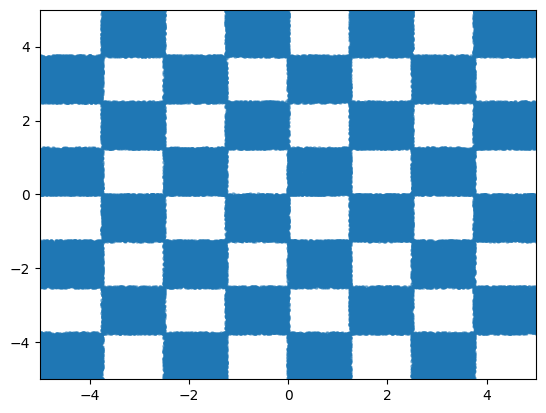

In [5]:
xs = generator.generate(100000, key=jax.random.PRNGKey(0))
xs_min, xs_max = xs.min(0), xs.max(0)
plt.scatter(xs[:, 0], xs[:, 1], s=5, alpha=0.5)
plt.xlim(xs_min[0], xs_max[0])
plt.ylim(xs_min[1], xs_max[1])

In [11]:

class BaseModel(nnx.Module):
    def __init__(self, d, rngs) -> None:
        self.time_embedding = GaussianFourierEmbedding(1,8, rngs=rngs)
        self.in_layer = GaussianFourierEmbedding(d,32, rngs=rngs)
        self.mlp = MLP([32,64,64,64,64,d], rngs=rngs, context_dim=8)

    def __call__(self, t,x, *args, **kwargs):
        time_embed = self.time_embedding(t)
        x = self.in_layer(x)
        output = self.mlp(x, context=time_embed)
        return output
d = xs.shape[-1]
net = BaseModel(d, nnx.Rngs(0))
model = EDM(net, std0=xs.std(0), loss_type="eps")
graphdef, params, state = nnx.split(model, nnx.Param, ...)
#model.train_cfg = EDMTrainingConfig(lognoise_scale=1., lognoise_mean=-0.5)

In [12]:

import optax

opt = optax.chain(optax.adaptive_grad_clip(10.), optax.adam(5e-4))
opt_state = opt.init(params)

def loss_fn(params, rng, x):
    model = nnx.merge(graphdef, params, state)
    return model.loss(rng, x)

@jax.jit
def update(params, opt_state, x, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng,x)
    updates, opt_state = opt.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

In [13]:
key = jax.random.key(0)

In [14]:
losses = []
gen = jax.jit(partial(generator.generate,1024))
for i in range(10):
    l = 0.
    for j in range(2000):
        key,key_data, key_loss = jax.random.split(key, 3)
        xs = gen(key_data)
        params, opt_state, loss = update(params, opt_state, xs,key_loss)
        l += loss
    print(l/2000)
    losses.append(l/2000)

1.8315836
1.788315
1.7777675
1.7751863
1.7725202
1.7708622
1.7696007
1.7680799
1.7671062
1.7675006


In [15]:
nnx.update(model, params)

In [19]:
from probjax.utils.odeint import odeint
from probjax.nn.nets.denoising_diffusion_configs import DDIMSolverConfig, VSolverConfig, EDMSolverConfig, EDMTrainingConfig

config = VSolverConfig(model.schedule)
config = DDIMSolverConfig(model.schedule)
config = EDMSolverConfig(model.schedule,ode_method="exp_ab2_scalarL")
model.set_solver_cfg(config)


def sample(rng):
    eps = jax.random.normal(rng, (d,)) * model.marginal_std(model.train_cfg.t_max)
    return model.sample_ode(eps, num_steps=256)

In [20]:
keys = jax.random.split(key, (100_000,))
xs = jax.jit(jax.vmap(sample))(keys)

(-4.999754905700684, 4.999896049499512)

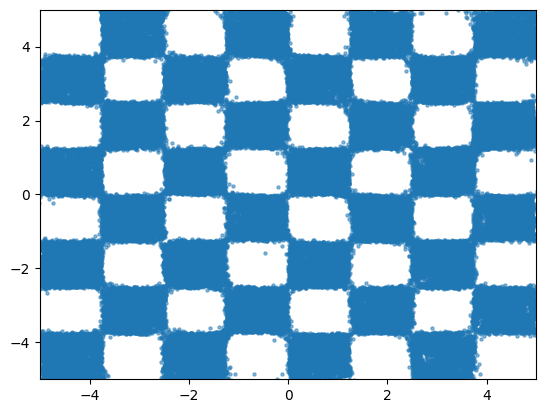

In [21]:
plt.scatter(xs[:, 0], xs[:, 1],  s=5, alpha=0.5)
plt.xlim(xs_min[0], xs_max[0])
plt.ylim(xs_min[1], xs_max[1])